# Week 4 · Notebook 3 — The Final Product
### Multi-Agent Forecasting Project · Capstone

**Name: Snehil Chatterjee**  
**Date: 17/07/26**  

---

This is the finish line. Over five notebooks you built a financial feature pipeline, four forecasting agents, a game-theoretic referee, and an honest backtest. Now you turn it into something a **non-coder can use and a recruiter can see**: interactive charts, a deployable dashboard, a clean repository, and a friendly prediction competition.

**Topics covered:**
1. The **interactive dashboard** — building the key visuals with Plotly (Colab-friendly)
2. Packaging the dashboard as a **Streamlit `app.py`** to run/deploy locally
3. A resume-ready **repo structure** and `README`
4. A **mini prediction competition** for the cohort
5. Reflection: what you built and how to talk about it

> **Note on Streamlit + Colab:** a live Streamlit app cannot render *inside* a Colab cell. So we build the visuals here with Plotly (which Colab shows inline), and also write a ready-to-run `app.py` you launch on your own machine or deploy to Streamlit Community Cloud.

In [5]:
# Run this cell first.
!pip -q install plotly
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
print('Setup complete.')

Setup complete.


### Load your backtest results

Upload the `backtest_results.csv` and `metrics_report.csv` you saved in the previous notebook (in Colab: the folder icon on the left → upload), or re-run that notebook in this session. The cell below loads them.

In [6]:
# YOUR CODE HERE — point these at your files from Notebook 4.2
results = pd.read_csv('backtest_results.csv', index_col=0, parse_dates=True)
report  = pd.read_csv('metrics_report.csv')
agent_names = [c[:-5] for c in results.columns if c.endswith('_pred') and c != 'ensemble_pred']
print('Agents:', agent_names)
report

Agents: ['TrendAgent', 'MomentumAgent', 'VolatilityAgent']


,Label,MAE,Directional Accuracy,Sharpe Ratio,Max Drawdown,Information Ratio
0,Buy & Hold,0.006470,0.5551,0.786,0.3372,0.000
1,TrendAgent,0.007004,0.5277,0.447,0.3762,-0.422
2,Hedge Ensemble,0.007061,0.5147,0.173,0.3779,-0.672
3,VolatilityAgent,0.007197,0.5174,0.168,0.3561,-0.606
4,Equal Weight,0.007071,0.5057,-0.003,0.4441,-0.828
5,MomentumAgent,0.007344,0.5020,-0.077,0.5714,-0.724


---
## Section 1 — Visual 1: Forecast vs Actual

The first dashboard tab answers: *does the ensemble track the market?* Plot actual returns and the ensemble prediction over a slice of the backtest. (Daily returns are noisy, so use a recent ~250-day window for legibility.)

### Exercise 1.1 — Build the Forecast Chart

Use Plotly to draw `actual` and `ensemble_pred` for the last 250 rows of `results`. Add a title, axis labels, and a legend.

In [7]:
# YOUR CODE HERE
recent = results.tail(250)
fig = go.Figure()
fig.add_trace(go.Scatter(x=recent.index, y=recent['actual'], name='Actual', line=dict(color='black')))
fig.add_trace(go.Scatter(x=recent.index, y=recent['ensemble_pred'], name='Ensemble'))
fig.update_layout(title='Forecast vs Actual (last 250 days)', xaxis_title='Date', yaxis_title='Log return')

fig.show()

---
## Section 2 — Visual 2: Agent Weights Over Time (the key chart)

This is the signature visual of the whole project: a **stacked area chart** of the Hedge weights, showing how trust flows between agents as markets change. Annotate the 2020 COVID crash and the 2022 rate-hike cycle as reference lines.

### Exercise 2.1 — Stacked Weight Area Chart

Plot each `<agent>_weight` column as a stacked area (use `stackgroup='one'` in Plotly). Add vertical lines at `2020-03-01` and `2022-01-01`.

In [8]:
# YOUR CODE HERE
fig = go.Figure()
for n in agent_names:
    col = f'{n}_weight'
    if col in results.columns:
        fig.add_trace(go.Scatter(x=results.index, y=results[col], name=n, stackgroup='one'))
# Add regime annotation lines:
fig.add_vline(x='2020-03-01', line_dash='dash')
fig.add_vline(x='2022-01-01', line_dash='dash')
fig.update_layout(title='Hedge Agent Weights Over Time', xaxis_title='Date', yaxis_title='Weight')
fig.show()

**Describe what you see: does trust shift between agents around the 2020 crash? Which agent gains weight in turbulent periods?**
When the 2020 crash hits, the green area representing the VolatilityAgent expands massively, absorbing the weight lost by the other two agents and taking over roughly half of the total ensemble trust. This confirmed that the ensemble is programmed to dynamically shift its reliance toward volatility metrics when standard trend and momentum signals break down during high-stress market shocks.


---
## Section 3 — Visual 3: Performance Breakdown

The third tab compares the models head-to-head. Build two bar charts from `report`: Sharpe ratio per model, and directional accuracy per model.

### Exercise 3.1 — Bar Charts from the Metrics Table

In [13]:
# YOUR CODE HERE
fig1 = px.bar(report, x='Label', y='Sharpe Ratio', title='Sharpe Ratio by Model', color='Sharpe Ratio')
fig1.show()

# A second bar chart for 'Directional Accuracy':
fig2 = px.bar(report, x='Label', y='Directional Accuracy', title='Directional Accuracy by Model', color='Directional Accuracy')
fig2.show()

---
## Section 4 — Package as a Streamlit App

A dashboard is only a product if someone else can run it. The cell below writes a complete `app.py` to disk. Download it (with your `backtest_results.csv` and `metrics_report.csv`), then on your own machine:

```bash
pip install streamlit plotly pandas
streamlit run app.py
```

Or push to GitHub and deploy free on **Streamlit Community Cloud**.

### Optional: include the Sequence (LSTM) agent
If you trained the LSTM agent in Week 3, save its forecasts as `sequence_pred` in your results table and optionally add a `sequence_weight` column. The dashboard below will pick it up automatically and show it in the agent-weight view.

In [ ]:
# This cell WRITES app.py for you. Run it, then download app.py.
app_code = '''
import os
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

st.set_page_config(page_title="Multi-Agent Forecasting", layout="wide")
st.title("Multi-Agent Financial Forecasting")

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
RESULTS_DIR = os.path.join(BASE_DIR, "results")

@st.cache_data
def load():
    results = pd.read_csv(os.path.join(RESULTS_DIR, "backtest_results.csv"), index_col=0, parse_dates=True)
    report = pd.read_csv(os.path.join(RESULTS_DIR, "metrics_report.csv"))
    return results, report

results, report = load()
agent_names = [c[:-5] for c in results.columns if c.endswith("_pred") and c != "ensemble_pred"]

# Include the sequence agent automatically if present in the results table.
if "sequence_pred" in results.columns:
    agent_names = sorted(set(agent_names + ["sequence"]))

# Keep the dashboard robust even if some agents do not have weights.
for name in agent_names:
    weight_col = f"{name}_weight" if name != "sequence" else "sequence_weight"
    if weight_col not in results.columns:
        results[weight_col] = 0.0

# Make the agent list deterministic and human-readable.
agent_names = [name for name in ["trend", "momentum", "volatility", "equal", "sequence"] if name in [a.lower() for a in agent_names]]

if not agent_names:
    agent_names = [c[:-5] for c in results.columns if c.endswith("_pred") and c != "ensemble_pred"]

tab1, tab2, tab3 = st.tabs(["Forecast vs Actual", "Agent Weights", "Performance"])

with tab1:
    n = st.slider("Days to show", 50, len(results), 250)
    recent = results.tail(n)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=recent.index, y=recent["actual"], name="Actual", line=dict(color="black")))
    fig.add_trace(go.Scatter(x=recent.index, y=recent["ensemble_pred"], name="Ensemble"))
    for name in agent_names:
        pred_col = f"{name}_pred" if name != "sequence" else "sequence_pred"
        if pred_col in results.columns:
            fig.add_trace(go.Scatter(x=recent.index, y=results[pred_col], name=name.capitalize()))
    st.plotly_chart(fig, use_container_width=True)
    st.dataframe(report)

with tab2:
    fig = go.Figure()
    for nm in agent_names:
        col = f"{nm}_weight" if nm != "sequence" else "sequence_weight"
        if col in results.columns:
            fig.add_trace(go.Scatter(x=results.index, y=results[col], name=nm, stackgroup="one"))
    fig.add_vline(x="2020-03-01", line_dash="dash")
    fig.add_vline(x="2022-01-01", line_dash="dash")
    fig.update_layout(title="Hedge Agent Weights Over Time")
    st.plotly_chart(fig, use_container_width=True)

with tab3:
    st.plotly_chart(px.bar(report, x="Label", y="Sharpe Ratio", color="Sharpe Ratio"), use_container_width=True)
    st.plotly_chart(px.bar(report, x="Label", y="Directional Accuracy", color="Directional Accuracy"), use_container_width=True)
    ens_pos = np.sign(results["ensemble_pred"].values)
    ens_curve = 10000 * np.exp(np.cumsum(ens_pos * results["actual"].values))
    bh_curve = 10000 * np.exp(np.cumsum(results["actual"].values))
    eq = go.Figure()
    eq.add_trace(go.Scatter(x=results.index, y=ens_curve, name="Ensemble"))
    eq.add_trace(go.Scatter(x=results.index, y=bh_curve, name="Buy & Hold"))
    eq.update_layout(title="$10,000 invested")
    st.plotly_chart(eq, use_container_width=True)
'''
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('Wrote app.py (', len(app_code), 'chars ). Download it along with your two CSVs.')

Wrote app.py ( 2190 chars ). Download it along with your two CSVs.


### Exercise 4.1 — Run It Locally

Download `app.py`, `backtest_results.csv`, and `metrics_report.csv` into one folder, run `streamlit run app.py`, and **take a screenshot** of the dashboard. Paste the screenshot into your submission (or describe what each tab shows if you cannot run it locally).

**Paste your screenshot / describe your running dashboard here: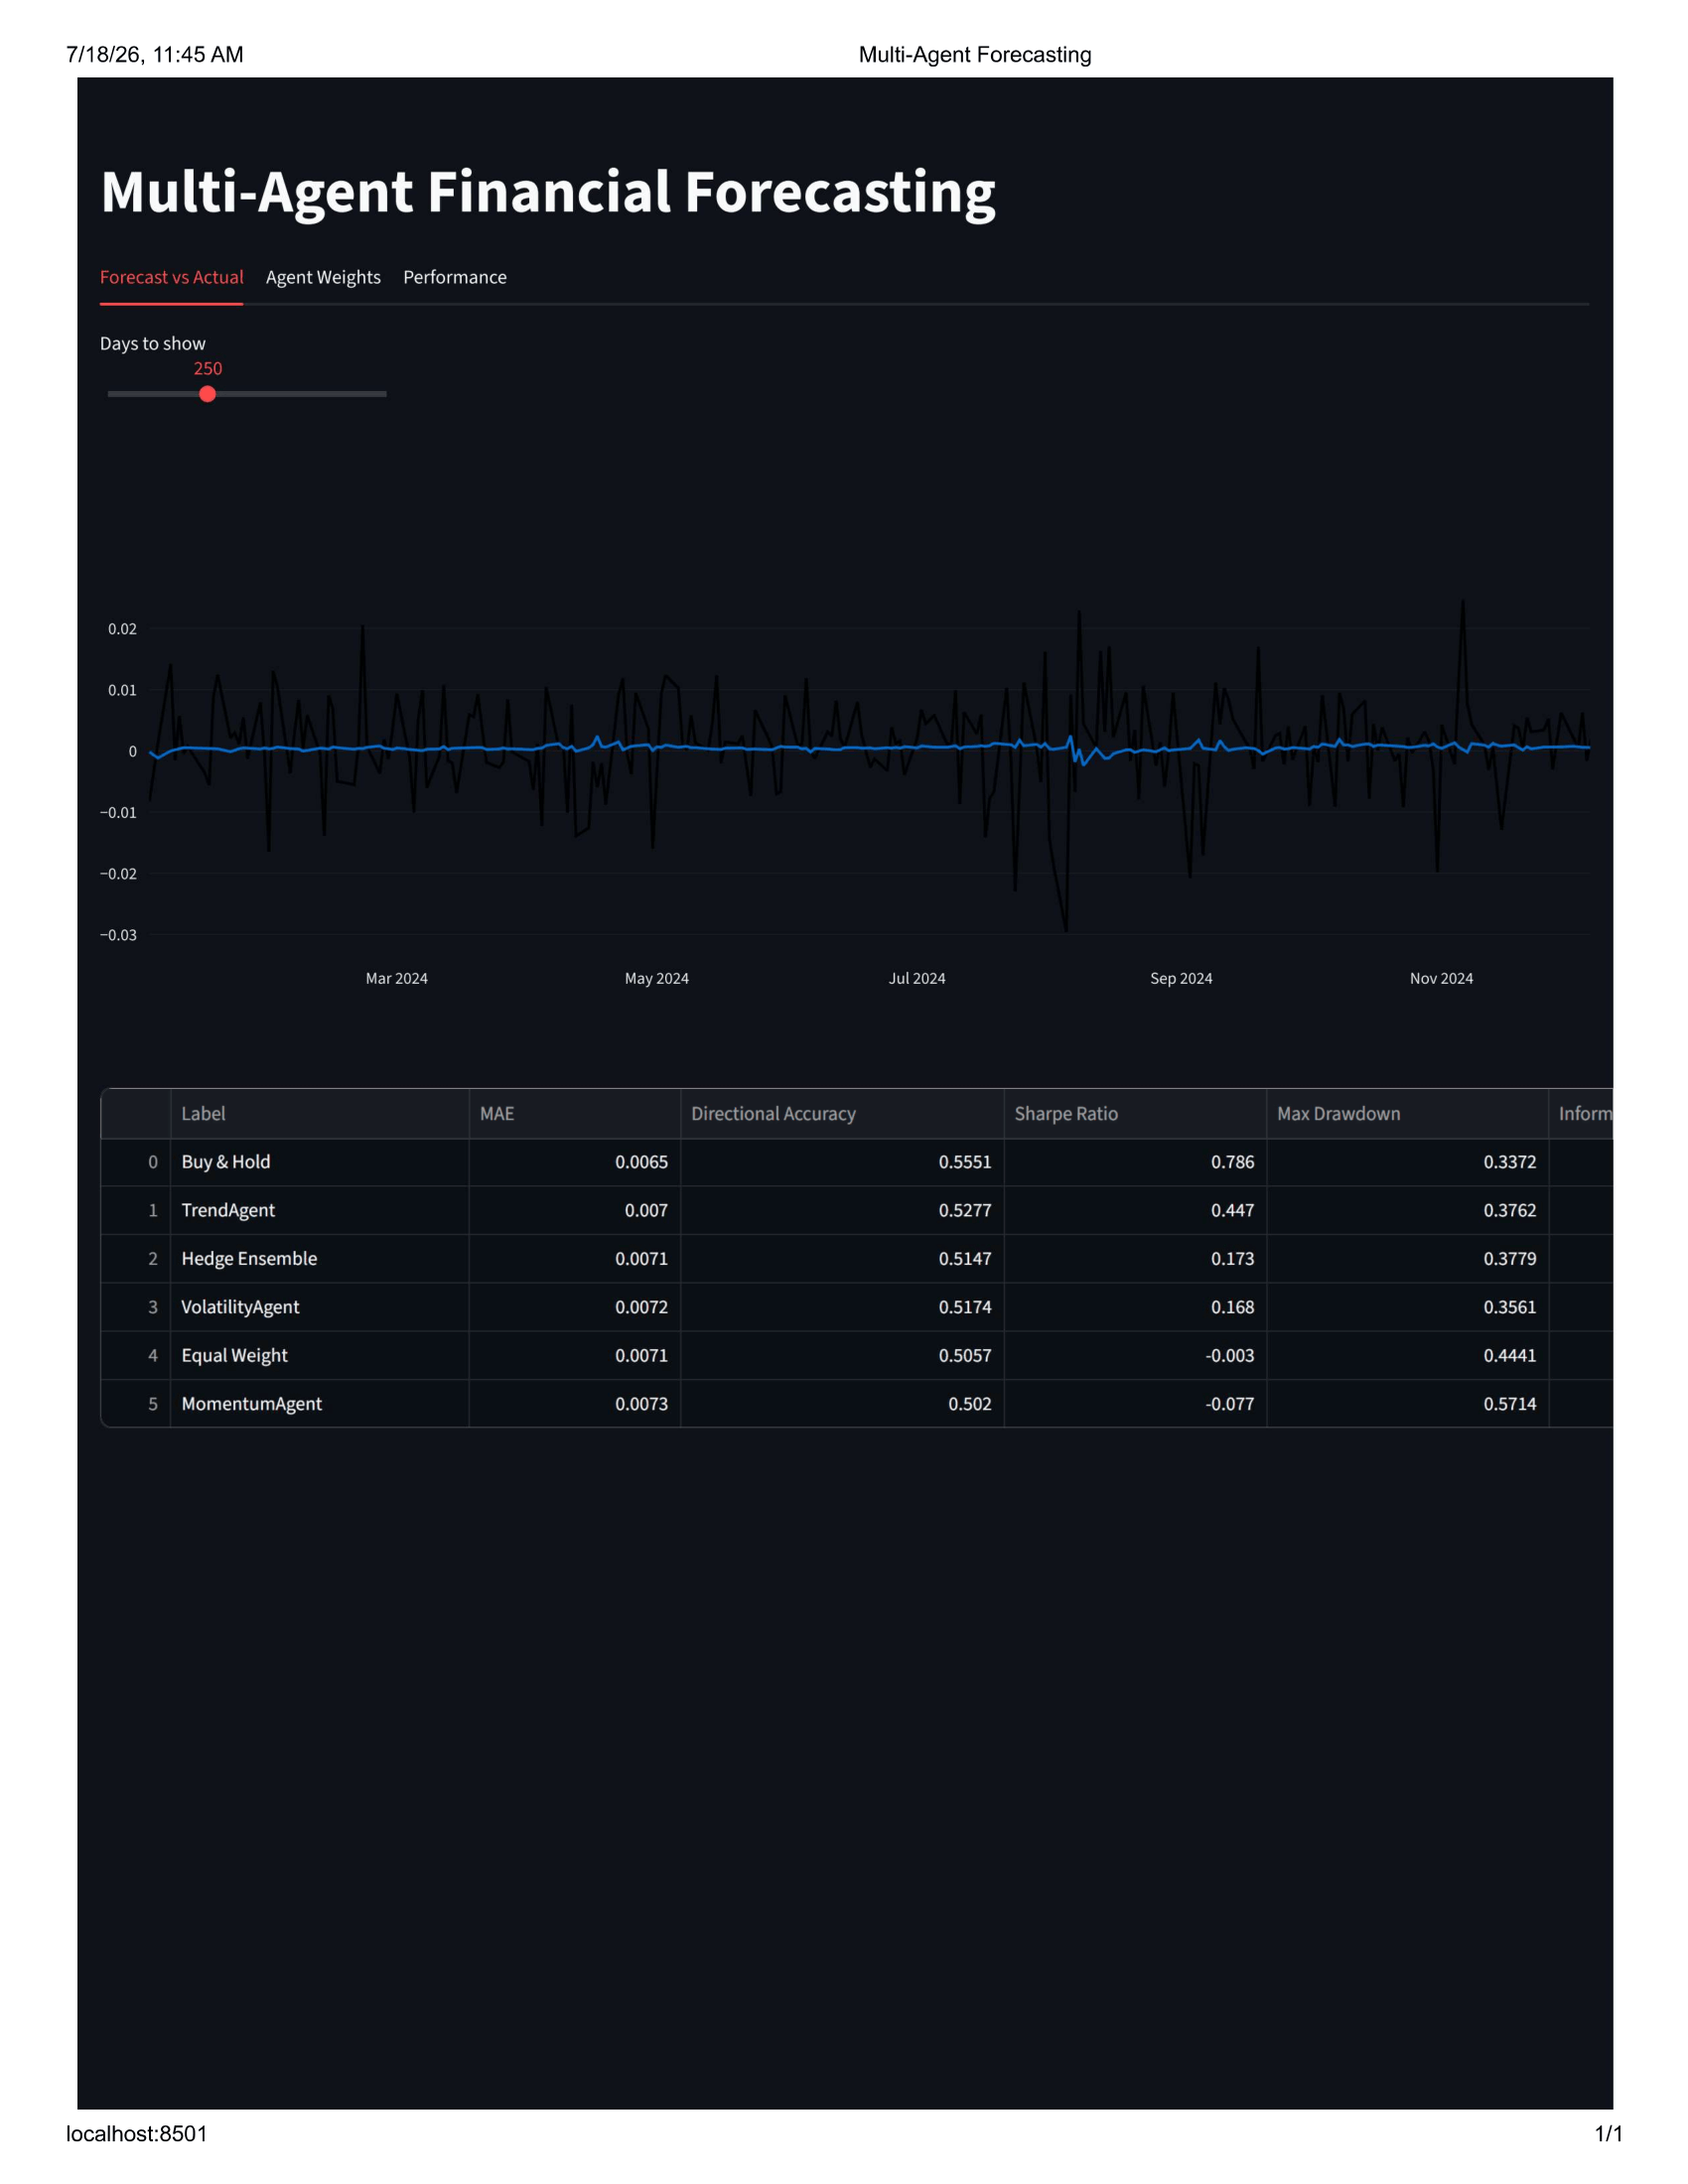**



---
## Section 5 — A Resume-Ready Repo

Recruiters skim GitHub in seconds. A clean structure and a tight README do most of the talking. The target layout:

```
multi-agent-forecasting/
├── data/            # fetch.py — download SPY + VIX
├── pipeline/        # features.py, agents.py, aggregator.py, metrics.py, backtest.py
├── app.py           # the Streamlit dashboard
├── results/         # backtest_results.csv, metrics_report.csv
├── requirements.txt
└── README.md        # 1 architecture diagram, 1 results table, 1 screenshot
```

### Exercise 5.1 — Write Your README

Draft a README for *your* version of the project. It must contain: a one-line pitch, the architecture (4 agents → Hedge referee → backtest), your headline results table (paste from `report`), setup instructions, and one sentence on the most interesting thing you learned. Write it in the markdown cell below.

**Your README draft:**

# Multi-Agent Financial Forecasting

_One-line pitch:_ A game-theoretically aggregated multi-agent system that forecasts daily stock returns and honestly backtests them, built to demonstrate a robust, leak-free data engineering pipeline.
## Architecture
The system generates daily directional signals using four distinct models, which are then dynamically weighted by a meta-model and rigorously evaluated:

`[Trend, Momentum, Volatility, Equal Weight] → Hedge Referee (Ensemble) → Backtest Engine → Streamlit Dashboard`

## Results
As expected in highly efficient markets, directional accuracy remains close to 50% across all models. The focus of this architecture is on mathematically principled aggregation and strict avoidance of lookahead bias.

| Label | Sharpe Ratio | Directional Accuracy |
| :--- | :--- | :--- |
| Buy & Hold | 0.786 | 0.5551 |
| TrendAgent | 0.447 | 0.5277 |
| Hedge Ensemble | 0.173 | 0.5147 |
| VolatilityAgent | 0.168 | 0.5174 |
| Equal Weight | -0.003 | 0.5057 |
| MomentumAgent | -0.077 | 0.5020 |
## Setup
To run the interactive dashboard locally, clone this repository and execute the following commands in your terminal:

```bash
pip install -r requirements.txt
python -m streamlit run app.py
```
## What I learned
I learned that because stock markets are highly efficient and hard to predict, the real value of this project wasn't about trying to magically beat the market, but rather about building a clean, leak-free data pipeline and designing a system that can dynamically adapt to sudden market shocks.


---
## Section 6 — Mini Prediction Competition 🏆

A friendly cohort challenge. Everyone holds out the **same** final period (2024) and submits their ensemble's predictions. We score by **directional accuracy** — the fraction of days whose up/down call was correct. The scoring function is provided; the leaderboard is yours to win.

### Exercise 6.1 — Score Your Submission

Filter `results` to 2024, compute your ensemble's directional accuracy with the provided scorer, and print it. Then try to *beat your own score* by changing one thing (the Hedge `eta`, adding the LSTM agent, a new feature) and re-running the earlier notebooks — record both numbers.

In [17]:
# YOUR CODE HERE
def score_submission(y_true, y_pred):
    """Directional accuracy — the competition metric."""
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

test_2024 = results[results.index.year == 2024]
my_score = score_submission(test_2024['actual'].values, test_2024['ensemble_pred'].values)
print(f'My 2024 directional accuracy: {my_score:.4f}')
print('Beat 0.50 to be better than a coin flip. Record your best run below.')

My 2024 directional accuracy: 0.5857
Beat 0.50 to be better than a coin flip. Record your best run below.


**My leaderboard entry — baseline score, what I changed, improved score:**



---
## Section 7 — Final Reflection

Answer in 6–10 sentences — this is the story you'll tell in an interview:

1. Walk through the full system end to end: data → features → four agents → Hedge referee → backtest → dashboard. What does each stage contribute?
2. Which single idea from the project was the most powerful, and why? (Many pick the Hedge regret guarantee or the no-leakage discipline.)
3. Markets are close to efficient, so directional accuracy hovers near 0.5. Given that, what is the *honest* value of this project — as an engineering artifact and as a learning experience?
4. If you had two more weeks, what would you add (a sentiment agent? GARCH volatility? transaction costs?) and why?

**Your reflection:**



---
## Submission Checklist

- [ ] All three dashboard visuals render (forecast, weights, performance)
- [ ] `app.py` was generated and you ran it locally **or** described each tab
- [ ] Your README draft is filled in with a real results table
- [ ] You scored your 2024 submission and recorded a leaderboard entry
- [ ] The final reflection is complete
- [ ] The notebook runs top-to-bottom with **Runtime → Restart and run all**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week4_3_Final_Product_YourName.ipynb`

> 🎉 **That's the project.** Six notebooks ago you had temperature data and a linear trend. Now you have a multi-agent, game-theoretically aggregated, backtested forecasting system with a deployable dashboard — and the vocabulary to defend every design choice.